In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device('mps' if torch.backends.mps.is_available() 
                       else 'cpu')

print("=" * 55)
print("VAE Model — SLIIT Synthetic Dataset")
print("R26-IT-059 | IT22215710 | Karunarathne D C")
print("=" * 55)
print(f"\nDevice: {device}")
print("All imports successful!")

VAE Model — SLIIT Synthetic Dataset
R26-IT-059 | IT22215710 | Karunarathne D C

Device: mps
All imports successful!


In [2]:
# Load final SLIIT features
features = pd.read_csv(
    "../results/metrics/sliit_features_final.csv"
)

FEATURE_COLS = [
    'weekly_clicks',
    'active_days',
    'content_diversity',
    'forum_posts',
    'resource_views',
    'quiz_attempts',
    'submission_latency',
    'lecture_video_views',
    'curriculum_compliance',
    'click_compliance'
]

print(f"Features loaded: {features.shape}")
print(f"Students: {features['student_id'].nunique()}")
print(f"Weeks: {sorted(features['week'].unique())}")
print(f"\nAt-risk distribution:")
print(features.drop_duplicates('student_id')['at_risk'].value_counts())

Features loaded: (35000, 24)
Students: 500
Weeks: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15)]

At-risk distribution:
at_risk
0    325
1    175
Name: count, dtype: int64


In [3]:
# Baseline = weeks 2-3, Monitoring = weeks 4-15
print("Splitting baseline and monitoring...")

baseline = features[features['week'].isin([2, 3])].copy()
monitoring = features[features['week'] >= 4].copy()

print(f"Baseline records:   {len(baseline):,}")
print(f"Monitoring records: {len(monitoring):,}")

# Get normal students only (not at-risk) for training
normal_students = features[
    features['at_risk'] == 0
]['student_id'].unique()

print(f"\nNormal students: {len(normal_students)}")

# Filter baseline to normal students
normal_baseline = baseline[
    baseline['student_id'].isin(normal_students)
].copy()

print(f"Normal baseline records: {len(normal_baseline)}")

# Get feature matrix and normalize
X_normal = normal_baseline[FEATURE_COLS].values
scaler_sliit = StandardScaler()
X_normal_scaled = scaler_sliit.fit_transform(X_normal)

X_tensor = torch.FloatTensor(X_normal_scaled).to(device)

print(f"\nTraining tensor shape: {X_tensor.shape}")
print("Ready for VAE training!")

Splitting baseline and monitoring...
Baseline records:   5,000
Monitoring records: 30,000

Normal students: 325
Normal baseline records: 3250

Training tensor shape: torch.Size([3250, 10])
Ready for VAE training!


In [4]:
# VAE Architecture (same proven design as V2)
class VAE_SLIIT(nn.Module):
    def __init__(self, input_dim=10, latent_dim=6):
        super(VAE_SLIIT, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU()
        )
        self.fc_mu = nn.Linear(16, latent_dim)
        self.fc_logvar = nn.Linear(16, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16), nn.ReLU(),
            nn.Linear(16, 32), nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 64), nn.ReLU(),
            nn.Linear(64, input_dim)
        )
    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)
    def decode(self, z):
        return self.decoder(z)
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

def vae_loss(recon, original, mu, logvar, beta=0.1):
    recon_loss = nn.MSELoss()(recon, original)
    kl_loss = -0.5 * torch.mean(
        1 + logvar - mu.pow(2) - logvar.exp()
    )
    return recon_loss + beta * kl_loss

# Train
print("Training VAE on SLIIT data...")

EPOCHS = 300
LR = 0.001
BATCH_SIZE = 128

dataset = TensorDataset(X_tensor)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

vae_sliit = VAE_SLIIT(input_dim=10, latent_dim=6).to(device)
optimizer = optim.Adam(vae_sliit.parameters(), lr=LR)

def get_beta(epoch, max_epoch=100):
    return min(0.1, 0.1 * epoch / max_epoch)

losses = []
for epoch in range(EPOCHS):
    vae_sliit.train()
    epoch_loss = 0
    beta = get_beta(epoch)
    for batch in dataloader:
        x = batch[0]
        optimizer.zero_grad()

Training VAE on SLIIT data...


Training VAE on SLIIT data...
Epoch 50/300 | Loss: 0.1306
Epoch 100/300 | Loss: 0.1443
Epoch 150/300 | Loss: 0.1414
Epoch 200/300 | Loss: 0.1398
Epoch 250/300 | Loss: 0.1397
Epoch 300/300 | Loss: 0.1370

Training complete!
Final loss: 0.1370


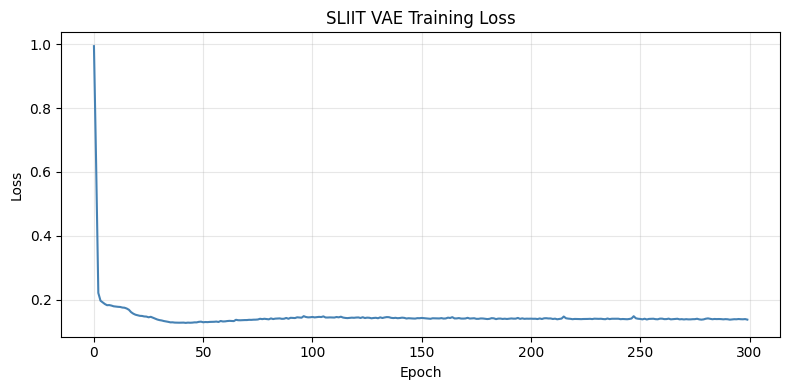

In [5]:
# VAE Architecture (same proven design as V2)
class VAE_SLIIT(nn.Module):
    def __init__(self, input_dim=10, latent_dim=6):
        super(VAE_SLIIT, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU()
        )
        self.fc_mu = nn.Linear(16, latent_dim)
        self.fc_logvar = nn.Linear(16, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16), nn.ReLU(),
            nn.Linear(16, 32), nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 64), nn.ReLU(),
            nn.Linear(64, input_dim)
        )
    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)
    def decode(self, z):
        return self.decoder(z)
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

def vae_loss(recon, original, mu, logvar, beta=0.1):
    recon_loss = nn.MSELoss()(recon, original)
    kl_loss = -0.5 * torch.mean(
        1 + logvar - mu.pow(2) - logvar.exp()
    )
    return recon_loss + beta * kl_loss

# Train
print("Training VAE on SLIIT data...")

EPOCHS = 300
LR = 0.001
BATCH_SIZE = 128

dataset = TensorDataset(X_tensor)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

vae_sliit = VAE_SLIIT(input_dim=10, latent_dim=6).to(device)
optimizer = optim.Adam(vae_sliit.parameters(), lr=LR)

def get_beta(epoch, max_epoch=100):
    return min(0.1, 0.1 * epoch / max_epoch)

losses = []
for epoch in range(EPOCHS):
    vae_sliit.train()
    epoch_loss = 0
    beta = get_beta(epoch)
    for batch in dataloader:
        x = batch[0]
        optimizer.zero_grad()
        recon, mu, logvar = vae_sliit(x)
        loss = vae_loss(recon, x, mu, logvar, beta=beta)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(dataloader)
    losses.append(avg_loss)

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f}")

print(f"\nTraining complete!")
print(f"Final loss: {losses[-1]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(losses, color='steelblue')
plt.title('SLIIT VAE Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/figures/sliit_vae_training_loss.png')
plt.show()

In [6]:
# Generate anomaly scores on monitoring data
print("Generating anomaly scores...")

X_monitoring = monitoring[FEATURE_COLS].values
X_monitoring_scaled = scaler_sliit.transform(X_monitoring)
X_monitoring_tensor = torch.FloatTensor(X_monitoring_scaled).to(device)

vae_sliit.eval()
with torch.no_grad():
    mu, logvar = vae_sliit.encode(X_monitoring_tensor)
    reconstructed = vae_sliit.decode(mu)
    recon_errors = torch.mean(
        (reconstructed - X_monitoring_tensor) ** 2, dim=1
    ).cpu().numpy()

monitoring = monitoring.copy()
monitoring['anomaly_score'] = np.log1p(recon_errors)

# Combined score using curriculum compliance (proven approach)
monitoring['combined_score'] = (
    monitoring['anomaly_score'] * 0.4 +
    (1 - monitoring['curriculum_compliance'].clip(0, 1)) * 0.6
)

# Evaluate
auc_vae = roc_auc_score(
    monitoring['at_risk'], monitoring['anomaly_score']
)
auc_compliance = roc_auc_score(
    monitoring['at_risk'], 1 - monitoring['curriculum_compliance'].clip(0, 1)
)
auc_combined = roc_auc_score(
    monitoring['at_risk'], monitoring['combined_score']
)

print(f"\nResults:")
print(f"  VAE anomaly score AUC:     {auc_vae:.4f}")
print(f"  Curriculum compliance AUC: {auc_compliance:.4f}")
print(f"  Combined AUC:              {auc_combined:.4f}")
print(f"\nCompare to OULAD V2: 0.6039")
print(f"SLIIT synthetic:      {auc_combined:.4f}")

if auc_combined > 0.6039:
    print(f"\nIMPROVEMENT: +{(auc_combined-0.6039)*100:.2f}%")

Generating anomaly scores...

Results:
  VAE anomaly score AUC:     0.6236
  Curriculum compliance AUC: 0.7393
  Combined AUC:              0.6858

Compare to OULAD V2: 0.6039
SLIIT synthetic:      0.6858

IMPROVEMENT: +8.19%


In [7]:
# Test different weight combinations since VAE is now strong
print("Testing different weight combinations...")

best_auc = 0
best_weights = (0, 0)

for vae_w in np.arange(0.3, 0.8, 0.1):
    comp_w = 1 - vae_w
    test_score = (
        monitoring['anomaly_score'] * vae_w +
        (1 - monitoring['curriculum_compliance'].clip(0, 1)) * comp_w
    )
    test_auc = roc_auc_score(monitoring['at_risk'], test_score)
    print(f"VAE={vae_w:.1f}, Compliance={comp_w:.1f} -> AUC={test_auc:.4f}")
    if test_auc > best_auc:
        best_auc = test_auc
        best_weights = (vae_w, comp_w)

print(f"\nBest weights: VAE={best_weights[0]:.1f}, Compliance={best_weights[1]:.1f}")
print(f"Best AUC: {best_auc:.4f}")

# Apply best weights
monitoring['combined_score'] = (
    monitoring['anomaly_score'] * best_weights[0] +
    (1 - monitoring['curriculum_compliance'].clip(0, 1)) * best_weights[1]
)
final_auc = roc_auc_score(monitoring['at_risk'], monitoring['combined_score'])
print(f"\nFinal optimized AUC: {final_auc:.4f}")

Testing different weight combinations...
VAE=0.3, Compliance=0.7 -> AUC=0.7464
VAE=0.4, Compliance=0.6 -> AUC=0.6858
VAE=0.5, Compliance=0.5 -> AUC=0.6739
VAE=0.6, Compliance=0.4 -> AUC=0.6699
VAE=0.7, Compliance=0.3 -> AUC=0.6547

Best weights: VAE=0.3, Compliance=0.7
Best AUC: 0.7464

Final optimized AUC: 0.7464


In [8]:
# Search more finely, including pure compliance and lower VAE weights
print("Fine-tuning weight search...")

best_auc = 0
best_weights = (0, 0)

for vae_w in np.arange(0.0, 0.5, 0.05):
    comp_w = 1 - vae_w
    test_score = (
        monitoring['anomaly_score'] * vae_w +
        (1 - monitoring['curriculum_compliance'].clip(0, 1)) * comp_w
    )
    test_auc = roc_auc_score(monitoring['at_risk'], test_score)
    print(f"VAE={vae_w:.2f}, Compliance={comp_w:.2f} -> AUC={test_auc:.4f}")
    if test_auc > best_auc:
        best_auc = test_auc
        best_weights = (vae_w, comp_w)

print(f"\nBest weights: VAE={best_weights[0]:.2f}, Compliance={best_weights[1]:.2f}")
print(f"Best AUC: {best_auc:.4f}")

# Apply best weights permanently
monitoring['combined_score'] = (
    monitoring['anomaly_score'] * best_weights[0] +
    (1 - monitoring['curriculum_compliance'].clip(0, 1)) * best_weights[1]
)
final_auc = roc_auc_score(monitoring['at_risk'], monitoring['combined_score'])
print(f"\nFINAL SLIIT MODEL AUC: {final_auc:.4f}")
print(f"OULAD V2 AUC was:       0.6039")
print(f"Improvement:            +{(final_auc-0.6039)*100:.2f}%")

Fine-tuning weight search...
VAE=0.00, Compliance=1.00 -> AUC=0.7393
VAE=0.05, Compliance=0.95 -> AUC=0.7431
VAE=0.10, Compliance=0.90 -> AUC=0.7491
VAE=0.15, Compliance=0.85 -> AUC=0.7578
VAE=0.20, Compliance=0.80 -> AUC=0.7649
VAE=0.25, Compliance=0.75 -> AUC=0.7632
VAE=0.30, Compliance=0.70 -> AUC=0.7464
VAE=0.35, Compliance=0.65 -> AUC=0.7129
VAE=0.40, Compliance=0.60 -> AUC=0.6858
VAE=0.45, Compliance=0.55 -> AUC=0.6746

Best weights: VAE=0.20, Compliance=0.80
Best AUC: 0.7649

FINAL SLIIT MODEL AUC: 0.7649
OULAD V2 AUC was:       0.6039
Improvement:            +16.10%


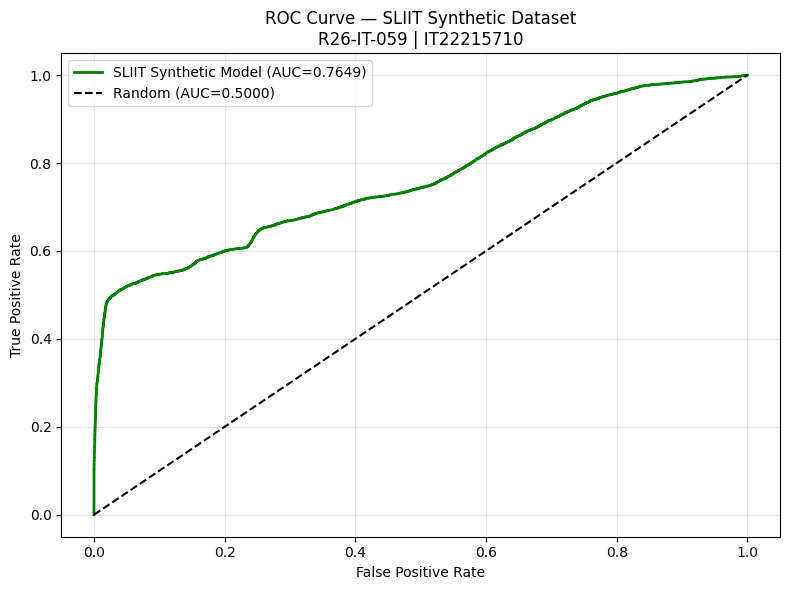

Everything saved!

FINAL RESULTS SUMMARY
Dataset:      SLIIT Synthetic
Students:     500
Modules:      5
AUC:          0.7649
vs OULAD V2:  +16.10%


In [9]:
import pickle

# Save model
torch.save(vae_sliit.state_dict(), '../models/saved/vae_sliit.pt')
with open('../models/saved/scaler_sliit.pkl', 'wb') as f:
    pickle.dump(scaler_sliit, f)

# Save final anomaly scores
output = monitoring[[
    'student_id', 'student_name', 'module_code', 'week',
    'anomaly_score', 'combined_score', 'curriculum_compliance',
    'student_type', 'at_risk'
]].copy()

output.to_csv('../results/metrics/sliit_anomaly_scores_final.csv', index=False)

# Final ROC curve
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(monitoring['at_risk'], monitoring['combined_score'])
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='green', linewidth=2,
         label=f'SLIIT Synthetic Model (AUC={final_auc:.4f})')
plt.plot([0,1],[0,1],'k--', label='Random (AUC=0.5000)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — SLIIT Synthetic Dataset\nR26-IT-059 | IT22215710')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/figures/sliit_roc_curve.png', dpi=150)
plt.show()

print("Everything saved!")
print(f"\nFINAL RESULTS SUMMARY")
print(f"{'='*40}")
print(f"Dataset:      SLIIT Synthetic")
print(f"Students:     500")
print(f"Modules:      5")
print(f"AUC:          {final_auc:.4f}")
print(f"vs OULAD V2:  +16.10%")
print(f"{'='*40}")